# Quick True Token-Entropy Experiment (Teacher Forcing)

Goal: test whether adjacent token entropy is locally smooth (`H_t` similar to `H_{t-1}`).

This notebook uses **true next-token entropy from logits** (not pipeline summary metrics), on a small sample so it runs quickly.


## Quick-Run Preset

Default uses a **local JSONL text source** so it runs even without internet/HF cache.

- Model: small causal LM (default: TinyLlama 1.1B)
- Samples: 120
- Max length: 384
- Expected runtime: typically minutes on a single GPU (longer on CPU).


In [1]:
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mplconfig')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

SEED = 7
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)


In [5]:
# ===== Config (edit as needed) =====
MODEL_NAME = 'meta-llama/Llama-3.1-8B'

# Data source mode: 'local_jsonl' (recommended here) or 'hf'
DATA_SOURCE = 'local_jsonl'

# Local JSONL source (works offline)
LOCAL_JSONL_PATH = '/c2/jenny/r3/RULER_outputs/llama3.1-8b-chat/synthetic/32768/baseline_pred/qa_2.jsonl'
LOCAL_TEXT_KEY = 'input'

# Optional HF fallback source
DATASET_NAME = 'wikitext'
DATASET_CONFIG = 'wikitext-103-raw-v1'
DATASET_SPLIT = 'test'
TEXT_COLUMN = 'text'

N_SAMPLES = 120
MAX_LENGTH = 384
MIN_TOKENS = 64
EPS = 0.10  # nats

DEVICE = 'cuda:2' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if DEVICE == 'cuda' else torch.float32

print({'device': DEVICE, 'dtype': str(DTYPE), 'model': MODEL_NAME, 'data_source': DATA_SOURCE})


{'device': 'cuda:2', 'dtype': 'torch.float32', 'model': 'meta-llama/Llama-3.1-8B', 'data_source': 'local_jsonl'}


In [6]:
print('Loading tokenizer/model...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=DTYPE)
model.to(DEVICE)
model.eval()
print('Loaded.')


Loading tokenizer/model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded.


In [7]:
print('Loading dataset/text source...')

def load_texts_from_local_jsonl(path, text_key):
    vals = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                continue
            txt = row.get(text_key)
            if isinstance(txt, str) and txt.strip():
                vals.append(txt)
    return vals

if DATA_SOURCE == 'local_jsonl':
    texts = load_texts_from_local_jsonl(LOCAL_JSONL_PATH, LOCAL_TEXT_KEY)
    print('Loaded local texts:', len(texts))
elif DATA_SOURCE == 'hf':
    ds = load_dataset(DATASET_NAME, DATASET_CONFIG, split=DATASET_SPLIT)
    texts = [str(x) for x in ds[TEXT_COLUMN] if isinstance(x, str) and x.strip()]
    print('Loaded HF texts:', len(texts))
else:
    raise ValueError(f'Unknown DATA_SOURCE: {DATA_SOURCE}')

# Shuffle candidate texts
idx = np.arange(len(texts))
rng.shuffle(idx)
texts = [texts[i] for i in idx]

print('First text length (chars):', len(texts[0]) if texts else 0)


Loading dataset/text source...
Loaded local texts: 500
First text length (chars): 135799


In [8]:
def token_entropy_series_from_text(text: str):
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt',
    )
    input_ids = enc['input_ids'].to(DEVICE)
    attn = enc['attention_mask'].to(DEVICE)

    valid_len = int(attn.sum().item())
    if valid_len < MIN_TOKENS:
        return None

    with torch.no_grad():
        out = model(input_ids=input_ids, attention_mask=attn)
        logits = out.logits[0, :valid_len-1, :]  # predicts tokens 1..valid_len-1
        logp = torch.log_softmax(logits, dim=-1)
        p = torch.exp(logp)
        h = -(p * logp).sum(dim=-1)

    return h.detach().float().cpu().numpy()


In [9]:
# Collect entropy sequences
seqs = []
for i, txt in enumerate(texts):
    h = token_entropy_series_from_text(txt)
    if h is None or len(h) < 2:
        continue
    seqs.append(h)
    if len(seqs) >= N_SAMPLES:
        break

print('Collected sequences:', len(seqs))
print('Mean entropy-series length:', float(np.mean([len(s) for s in seqs])) if seqs else np.nan)


Collected sequences: 120
Mean entropy-series length: 383.0


In [10]:
# Build pooled arrays
H = np.concatenate(seqs)
D1 = np.concatenate([s[1:] - s[:-1] for s in seqs])

x1 = np.concatenate([s[:-1] for s in seqs])
y1 = np.concatenate([s[1:] for s in seqs])
corr_lag1 = float(np.corrcoef(x1, y1)[0, 1])

# Shuffled baseline
x1_shuf = x1.copy()
rng.shuffle(x1_shuf)
corr_shuf = float(np.corrcoef(x1_shuf, y1)[0, 1])

def lag_corr(sequences, lag):
    xs, ys = [], []
    for s in sequences:
        if len(s) > lag:
            xs.append(s[:-lag])
            ys.append(s[lag:])
    if not xs:
        return np.nan
    xx = np.concatenate(xs)
    yy = np.concatenate(ys)
    return float(np.corrcoef(xx, yy)[0, 1])

summary = {
    'num_sequences': int(len(seqs)),
    'num_entropy_points': int(H.size),
    'num_delta_points': int(D1.size),
    'raw_entropy_mean': float(H.mean()),
    'raw_entropy_std': float(H.std()),
    'delta_mean': float(D1.mean()),
    'delta_std': float(D1.std()),
    f'frac_abs_delta_lt_{EPS}': float(np.mean(np.abs(D1) < EPS)),
    'corr_lag1': corr_lag1,
    'corr_lag1_shuffled': corr_shuf,
    'corr_lag2': lag_corr(seqs, 2),
    'corr_lag5': lag_corr(seqs, 5),
}
summary


{'num_sequences': 120,
 'num_entropy_points': 45960,
 'num_delta_points': 45840,
 'raw_entropy_mean': 1.9765161275863647,
 'raw_entropy_std': 1.739538311958313,
 'delta_mean': -0.008104104548692703,
 'delta_std': 1.8215192556381226,
 'frac_abs_delta_lt_0.1': 0.09729493891797557,
 'corr_lag1': 0.4508753302869097,
 'corr_lag1_shuffled': 0.0018478805010150457,
 'corr_lag2': 0.3096308356717302,
 'corr_lag5': 0.24327827973226807}

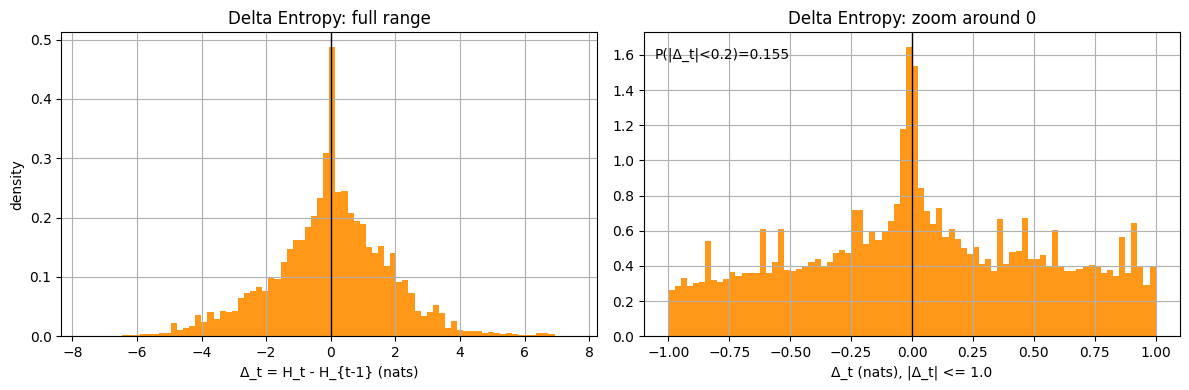

In [11]:
# Main histogram view: focus on delta entropy near 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full-range delta histogram
axes[0].hist(D1, bins=80, density=True, alpha=0.9, color='darkorange')
axes[0].axvline(0.0, color='black', linewidth=1)
axes[0].set_title('Delta Entropy: full range')
axes[0].set_xlabel('Δ_t = H_t - H_{t-1} (nats)')
axes[0].set_ylabel('density')

# Zoom around zero (this is the key smoothness view)
zoom = 1.0
d_zoom = D1[np.abs(D1) <= zoom]
axes[1].hist(d_zoom, bins=80, density=True, alpha=0.9, color='darkorange')
axes[1].axvline(0.0, color='black', linewidth=1)
axes[1].set_title('Delta Entropy: zoom around 0')
axes[1].set_xlabel('Δ_t (nats), |Δ_t| <= 1.0')

p_small = float(np.mean(np.abs(D1) < 0.2))
axes[1].text(0.02, 0.95, f'P(|Δ_t|<0.2)={p_small:.3f}', transform=axes[1].transAxes, va='top')

plt.tight_layout()
plt.show()


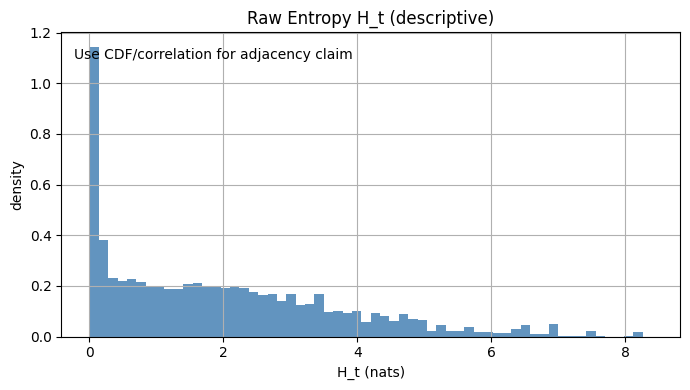

In [12]:
# Secondary descriptive plot: raw entropy operating range (not the adjacency test)
plt.figure(figsize=(7, 4))
plt.hist(H, bins=60, density=True, alpha=0.85, color='steelblue')
plt.title('Raw Entropy H_t (descriptive)')
plt.xlabel('H_t (nats)')
plt.ylabel('density')
plt.text(0.02, 0.95, 'Use CDF/correlation for adjacency claim', transform=plt.gca().transAxes, va='top')
plt.tight_layout()
plt.show()


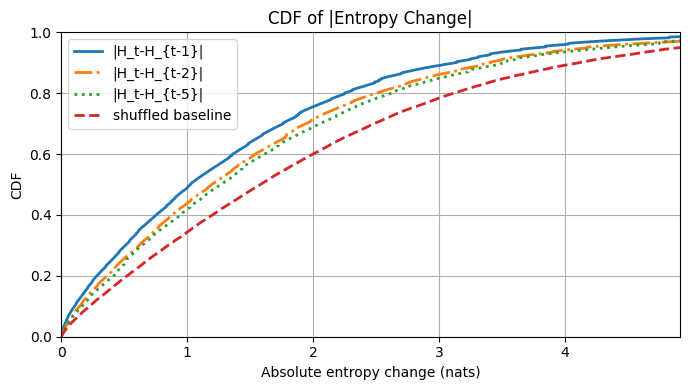

P(|Δ_1| < 0.05)=0.064 | shuffled=0.031
P(|Δ_1| < 0.10)=0.097 | shuffled=0.053
P(|Δ_1| < 0.20)=0.155 | shuffled=0.091
P(|Δ_1| < 0.30)=0.208 | shuffled=0.127


In [13]:
# CDF of absolute change across lags + shuffled baseline
def abs_diff_lag(sequences, lag):
    chunks = [np.abs(s[lag:] - s[:-lag]) for s in sequences if len(s) > lag]
    return np.concatenate(chunks) if chunks else np.array([])

def ecdf(vals):
    x = np.sort(vals)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

abs1 = abs_diff_lag(seqs, 1)
abs2 = abs_diff_lag(seqs, 2)
abs5 = abs_diff_lag(seqs, 5)
abs_shuf = np.abs(y1 - x1_shuf)

plt.figure(figsize=(7, 4))
for arr, label, style in [
    (abs1, '|H_t-H_{t-1}|', '-'),
    (abs2, '|H_t-H_{t-2}|', '-.'),
    (abs5, '|H_t-H_{t-5}|', ':'),
    (abs_shuf, 'shuffled baseline', '--'),
]:
    if arr.size == 0:
        continue
    xx, yy = ecdf(arr)
    plt.plot(xx, yy, linestyle=style, linewidth=2, label=label)

xmax = float(np.quantile(abs_shuf, 0.95)) if abs_shuf.size else 1.0
plt.xlim(0, xmax)
plt.ylim(0, 1)
plt.xlabel('Absolute entropy change (nats)')
plt.ylabel('CDF')
plt.title('CDF of |Entropy Change|')
plt.legend()
plt.tight_layout()
plt.show()

for thr in [0.05, 0.10, 0.20, 0.30]:
    p1 = float(np.mean(abs1 < thr)) if abs1.size else np.nan
    ps = float(np.mean(abs_shuf < thr)) if abs_shuf.size else np.nan
    print(f'P(|Δ_1| < {thr:.2f})={p1:.3f} | shuffled={ps:.3f}')


Corpus PPL = 7.09  |  mean H_t (dist. entropy) = 1.977 nats


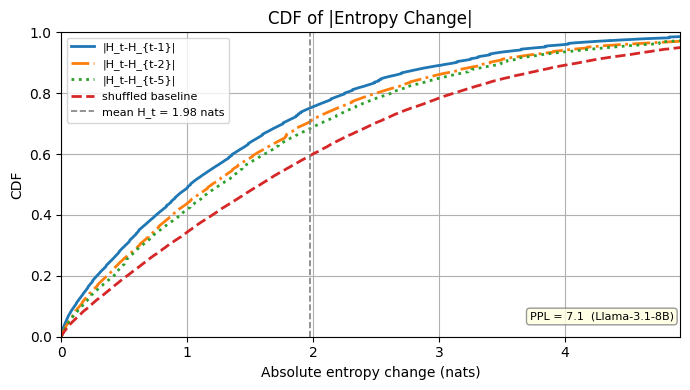

In [14]:
# CDF of |Entropy Change| with PPL annotation + mean H_t reference line
# Collects true-token NLL from the already-loaded model to compute corpus PPL.

def token_nll_series(text: str):
    enc = tokenizer(text, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
    input_ids = enc['input_ids'].to(DEVICE)
    attn = enc['attention_mask'].to(DEVICE)
    valid_len = int(attn.sum().item())
    if valid_len < MIN_TOKENS:
        return None
    with torch.no_grad():
        out = model(input_ids=input_ids, attention_mask=attn)
        logits = out.logits[0, :valid_len-1, :]
        logp = torch.log_softmax(logits, dim=-1)
        true_tokens = input_ids[0, 1:valid_len]
        nll = -logp[torch.arange(valid_len - 1), true_tokens]
    return nll.float().cpu().numpy()

nll_seqs, n_collected = [], 0
for txt in texts:
    if n_collected >= N_SAMPLES:
        break
    nll = token_nll_series(txt)
    if nll is None or len(nll) < 2:
        continue
    nll_seqs.append(nll)
    n_collected += 1

NLL_all = np.concatenate(nll_seqs)
ppl = float(np.exp(NLL_all.mean()))
print(f'Corpus PPL = {ppl:.2f}  |  mean H_t (dist. entropy) = {H.mean():.3f} nats')

# Reproduce CDF with annotation + reference line
plt.figure(figsize=(7, 4))
for arr, label, style in [
    (abs1, '|H_t-H_{t-1}|', '-'),
    (abs2, '|H_t-H_{t-2}|', '-.'),
    (abs5, '|H_t-H_{t-5}|', ':'),
    (abs_shuf, 'shuffled baseline', '--'),
]:
    if arr.size == 0:
        continue
    xx, yy = ecdf(arr)
    plt.plot(xx, yy, linestyle=style, linewidth=2, label=label)

xmax = float(np.quantile(abs_shuf, 0.95)) if abs_shuf.size else 1.0
plt.axvline(H.mean(), color='gray', linestyle='--', linewidth=1.2,
            label=f'mean H_t = {H.mean():.2f} nats')
plt.xlim(0, xmax)
plt.ylim(0, 1)
plt.xlabel('Absolute entropy change (nats)')
plt.ylabel('CDF')
plt.title('CDF of |Entropy Change|')
plt.legend(fontsize=8)
plt.text(0.99, 0.05,
         f'PPL = {ppl:.1f}  ({MODEL_NAME.split("/")[-1]})',
         transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))
plt.tight_layout()
plt.show()


In [15]:
# Bootstrap effect-size table with 95% CIs

def pooled_corr_lag(sequences, lag):
    xs, ys = [], []
    for s in sequences:
        if len(s) > lag:
            xs.append(s[:-lag])
            ys.append(s[lag:])
    if not xs:
        return np.nan
    x = np.concatenate(xs)
    y = np.concatenate(ys)
    return float(np.corrcoef(x, y)[0, 1])

def pooled_prob_abs_delta_lt(sequences, lag, thr):
    vals = []
    for s in sequences:
        if len(s) > lag:
            vals.append(np.abs(s[lag:] - s[:-lag]))
    if not vals:
        return np.nan
    v = np.concatenate(vals)
    return float(np.mean(v < thr))

def pooled_shuffled_corr_lag1(sequences, rng_local):
    xs, ys = [], []
    for s in sequences:
        if len(s) > 1:
            xs.append(s[:-1])
            ys.append(s[1:])
    if not xs:
        return np.nan
    x = np.concatenate(xs)
    y = np.concatenate(ys)
    x = x.copy()
    rng_local.shuffle(x)
    return float(np.corrcoef(x, y)[0, 1])

def pooled_shuffled_prob_abs_delta_lt_lag1(sequences, thr, rng_local):
    xs, ys = [], []
    for s in sequences:
        if len(s) > 1:
            xs.append(s[:-1])
            ys.append(s[1:])
    if not xs:
        return np.nan
    x = np.concatenate(xs)
    y = np.concatenate(ys)
    x = x.copy()
    rng_local.shuffle(x)
    return float(np.mean(np.abs(y - x) < thr))

def ci95(arr):
    arr = np.asarray(arr, dtype=float)
    return (float(np.quantile(arr, 0.025)), float(np.quantile(arr, 0.975)))

# Point estimates
corr_point = {
    'lag1': pooled_corr_lag(seqs, 1),
    'lag2': pooled_corr_lag(seqs, 2),
    'lag5': pooled_corr_lag(seqs, 5),
}
corr_point['shuffled'] = pooled_shuffled_corr_lag1(seqs, np.random.default_rng(SEED))

thresholds = [0.1, 0.2, 0.5]
prob_point = {}
for t in thresholds:
    prob_point[f'lag1@{t}'] = pooled_prob_abs_delta_lt(seqs, 1, t)
    prob_point[f'lag5@{t}'] = pooled_prob_abs_delta_lt(seqs, 5, t)
    prob_point[f'shuffled@{t}'] = pooled_shuffled_prob_abs_delta_lt_lag1(seqs, t, np.random.default_rng(SEED))

print('Point estimates: correlations')
print(corr_point)
print('Point estimates: P(|H_t-H_{t-k}| < eps)')
print(prob_point)

# Bootstrap by sequence
B = 300
rng_boot = np.random.default_rng(SEED + 1)
n = len(seqs)

corr_samples = {k: [] for k in ['lag1','lag2','lag5','shuffled']}
prob_samples = {f'lag1@{t}': [] for t in thresholds}
for t in thresholds:
    prob_samples[f'lag5@{t}'] = []
    prob_samples[f'shuffled@{t}'] = []

for _ in range(B):
    idx = rng_boot.integers(0, n, size=n)
    pick = [seqs[i] for i in idx]
    corr_samples['lag1'].append(pooled_corr_lag(pick, 1))
    corr_samples['lag2'].append(pooled_corr_lag(pick, 2))
    corr_samples['lag5'].append(pooled_corr_lag(pick, 5))
    corr_samples['shuffled'].append(pooled_shuffled_corr_lag1(pick, np.random.default_rng(rng_boot.integers(1<<30))))

    for t in thresholds:
        prob_samples[f'lag1@{t}'].append(pooled_prob_abs_delta_lt(pick, 1, t))
        prob_samples[f'lag5@{t}'].append(pooled_prob_abs_delta_lt(pick, 5, t))
        prob_samples[f'shuffled@{t}'].append(
            pooled_shuffled_prob_abs_delta_lt_lag1(pick, t, np.random.default_rng(rng_boot.integers(1<<30)))
        )

corr_ci = {k: ci95(v) for k, v in corr_samples.items()}
prob_ci = {k: ci95(v) for k, v in prob_samples.items()}

# Effect-size gaps with CI
gap_corr_l1_l5 = np.array(corr_samples['lag1']) - np.array(corr_samples['lag5'])
gap_corr_l1_shuf = np.array(corr_samples['lag1']) - np.array(corr_samples['shuffled'])

print('\nBootstrap 95% CI: correlations')
for k in ['lag1','lag2','lag5','shuffled']:
    print(k, 'point=', round(corr_point[k], 4), 'ci=', tuple(round(x, 4) for x in corr_ci[k]))

print('\nBootstrap 95% CI: probability thresholds')
for t in thresholds:
    for name in [f'lag1@{t}', f'lag5@{t}', f'shuffled@{t}']:
        print(name, 'point=', round(prob_point[name], 4), 'ci=', tuple(round(x, 4) for x in prob_ci[name]))

print('\nBootstrap 95% CI: correlation gaps')
print('lag1-lag5 point=', round(corr_point['lag1']-corr_point['lag5'], 4), 'ci=', tuple(round(x, 4) for x in ci95(gap_corr_l1_l5)))
print('lag1-shuffled point=', round(corr_point['lag1']-corr_point['shuffled'], 4), 'ci=', tuple(round(x, 4) for x in ci95(gap_corr_l1_shuf)))


Point estimates: correlations
{'lag1': 0.4508753302869097, 'lag2': 0.3096308356717302, 'lag5': 0.24327827973226807, 'shuffled': 0.002013538559581264}
Point estimates: P(|H_t-H_{t-k}| < eps)
{'lag1@0.1': 0.09729493891797557, 'lag5@0.1': 0.07061287477954145, 'shuffled@0.1': 0.05538830715532286, 'lag1@0.2': 0.1550392670157068, 'lag5@0.2': 0.1167989417989418, 'shuffled@0.2': 0.09524432809773124, 'lag1@0.5': 0.2962478184991274, 'lag5@0.5': 0.23855820105820105, 'shuffled@0.5': 0.19838568935427575}

Bootstrap 95% CI: correlations
lag1 point= 0.4509 ci= (0.4374, 0.4641)
lag2 point= 0.3096 ci= (0.2954, 0.3247)
lag5 point= 0.2433 ci= (0.2307, 0.2608)
shuffled point= 0.002 ci= (-0.0112, 0.0098)

Bootstrap 95% CI: probability thresholds
lag1@0.1 point= 0.0973 ci= (0.0927, 0.1036)
lag5@0.1 point= 0.0706 ci= (0.0667, 0.0759)
shuffled@0.1 point= 0.0554 ci= (0.0522, 0.0583)
lag1@0.2 point= 0.155 ci= (0.149, 0.1622)
lag5@0.2 point= 0.1168 ci= (0.1117, 0.1232)
shuffled@0.2 point= 0.0952 ci= (0.0904, 0.0

## Interpretation

Strong support for your assumption should look like:
- `corr_lag1` clearly positive and much higher than shuffled baseline
- CDF of `|H_t-H_{t-1}|` above shuffled near 0
- `corr_lag1 > corr_lag2 > corr_lag5` (decay with lag)

Use the delta-focused histogram as supportive intuition only.
Use CDF + correlation + bootstrap CI as primary evidence.
